In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Quick Overview Of The Project

We have dataset of past sales of heavy equipment (bulldozers, excavators, etc.) — things like the machine's age, how many hours it's been used, its cabin type, where it sold, and crucially, what it actually sold for. From this dataset I have to predict price of a new machine from the old sales.This is a **Regression problem**(continuous numerical output)

# Importing necessary libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import r2_score
from sklearn.preprocessing import OrdinalEncoder

# Model imports
from sklearn.linear_model import Ridge
from sklearn.svm import LinearSVR
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


**Here the target column or output column(Y) is - Price and other columns are called descriptive columns or Input(X)**


# Data Loading

In [4]:
train = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')
test = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv')
sample_sub= pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv')

In [5]:
train.shape

(138701, 50)

In [6]:
test.shape

(15000, 49)

In [7]:
train.head()

,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,...,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


In [8]:
test.head()

,TransactionID,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,Spec_FullDescriptor,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139307,999097,3168,ACH138,GTX,2005,68.0,Low,2007-11-16,521D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139419,1018084,1344,ACH138,GTX,1999,10466.0,Medium,2007-06-01,345BL,...,Steel,None or Unspecified,"15' 9""",None or Unspecified,Yes,Double,NaN,NaN,NaN,NaN
2,1139482,1048712,2808,ACH138,GTX,2001,3817.0,Low,2012-06-16,EX120-5,...,Steel,None or Unspecified,None or Unspecified,Hydraulic,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139522,697537,1089,ACH138,GTX,2006,1498.0,Medium,2010-08-27,304CR,...,Rubber,16 inch,None or Unspecified,Manual,Yes,Double,NaN,NaN,NaN,NaN
4,1139684,1048082,16781,ACH138,GTX,2009,22.0,Low,2010-07-09,L2800D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  object 
 5   VendorPartnerID            138701 non-null  object 
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   object 
 9   TransactionDate            138701 non-null  object 
 10  Spec_FullDescriptor        138701 non-null  object 
 11  Spec_BaseClass             138701 non-null  object 
 12  Spec_SubClass              101716 non-null  object 
 13  Spec_ReleaseSeries         32

In [10]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 49 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   TransactionID              15000 non-null  int64  
 1   AssetID                    15000 non-null  int64  
 2   ProductConfigID            15000 non-null  int64  
 3   DataOriginCode             15000 non-null  object 
 4   VendorPartnerID            15000 non-null  object 
 5   ManufactureYear            15000 non-null  int64  
 6   OperationalHoursMeter      8809 non-null   float64
 7   UtilizationTier            5356 non-null   object 
 8   TransactionDate            15000 non-null  object 
 9   Spec_FullDescriptor        15000 non-null  object 
 10  Spec_BaseClass             15000 non-null  object 
 11  Spec_SubClass              11006 non-null  object 
 12  Spec_ReleaseSeries         3505 non-null   object 
 13  Spec_VariantModifier       5609 non-null   obj

# EDA

**1.Data Types**

*Checking which columns are num columns and which are object columns to check skewness , missing values*

In [11]:
print("Train Data Types:")
print(train.dtypes.value_counts())

num_columns = train.select_dtypes(include=np.number).columns.tolist()
obj_columns = train.select_dtypes(include='object').columns.tolist()
print(f"\nNumerical columns ({len(num_columns)}):", num_columns[:10])
print(f"Categorical columns ({len(obj_columns)}):", obj_columns[:10])

Train Data Types:
object     44
int64       4
float64     2
Name: count, dtype: int64

Numerical columns (6): ['TransactionID', 'TargetValue', 'AssetID', 'ProductConfigID', 'ManufactureYear', 'OperationalHoursMeter']
Categorical columns (44): ['DataOriginCode', 'VendorPartnerID', 'UtilizationTier', 'TransactionDate', 'Spec_FullDescriptor', 'Spec_BaseClass', 'Spec_SubClass', 'Spec_ReleaseSeries', 'Spec_VariantModifier', 'AssetScaleFactor']


**2.Descriptive Statistics**

In [12]:
train.describe()

,TransactionID,TargetValue,AssetID,ProductConfigID,ManufactureYear,OperationalHoursMeter
count,1.387010e+05,138701.000000,1.387010e+05,138701.000000,138701.000000,8.205800e+04
mean,2.186276e+06,41521.874047,1.204814e+06,7286.421922,1891.640853,4.553719e+03
std,1.128497e+06,26361.125948,5.287376e+05,7542.421537,306.992001,2.792204e+04
min,1.139309e+06,7500.000000,8.000000e+00,39.000000,1001.000000,0.000000e+00
25%,1.465754e+06,20500.000000,1.007930e+06,1693.000000,1990.000000,0.000000e+00
50%,1.751884e+06,35000.000000,1.246956e+06,3852.000000,1998.000000,1.620000e+03
75%,2.372139e+06,57000.000000,1.495817e+06,11873.000000,2004.000000,5.001000e+03
max,6.333410e+06,142000.000000,2.478476e+06,37209.000000,2015.000000,1.729600e+06


**3. Missing Values**

In [13]:
print('Missing values in Train Dataset (showing columns with missing values):')
missing_train = train.isnull().sum()
print(missing_train[missing_train > 0].sort_values(ascending=False).head(15))

print('\nMissing values in Test Dataset (showing columns with missing values):')
missing_test = test.isnull().sum()
print(missing_test[missing_test > 0].sort_values(ascending=False).head(15))

Missing values in Train Dataset (showing columns with missing values):
col18    138635
col19    138635
col4     128320
col5     128320
col28    123742
col27    123742
col30    119829
col29    119829
col14    115296
col11    115296
col13    115296
col8     115296
col9     115296
col6     115296
col7     115296
dtype: int64

Missing values in Test Dataset (showing columns with missing values):
col18    14986
col19    14986
col4     13878
col5     13878
col28    13439
col27    13439
col30    13041
col29    13041
col14    12422
col11    12422
col13    12422
col8     12422
col9     12422
col6     12422
col7     12422
dtype: int64


**4. Target skewness visualization**

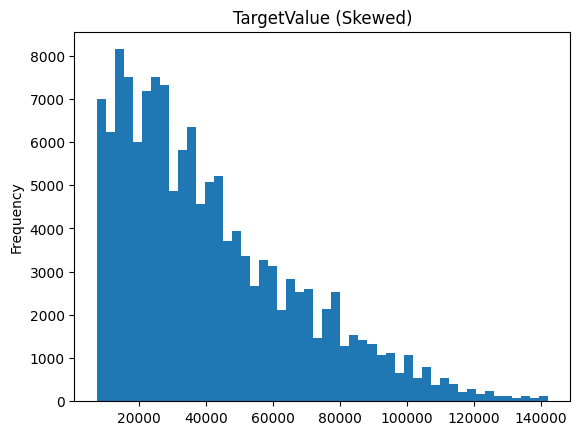

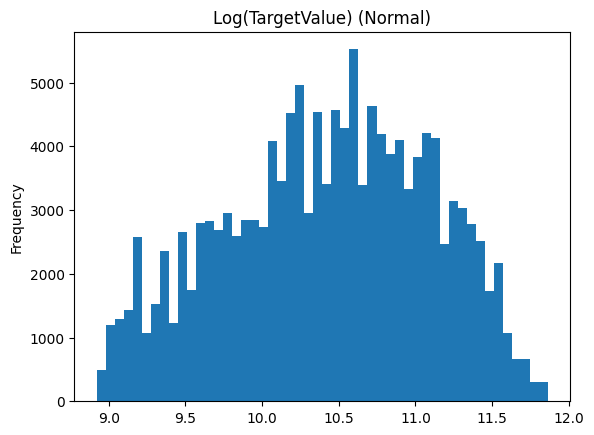

In [14]:
#Plot Skewed target
train['TargetValue'].plot(kind='hist', bins=50, title='TargetValue (Skewed)')
plt.show()

# Plot log-transformed target 
np.log(train['TargetValue']).plot(kind='hist', bins=50, title='Log(TargetValue) (Normal)')
plt.show()

**Inference:**
- **TargetValue(Resale Price)** is heavily right-skewed — most equipment sells in the lower-to-mid price range, with a long tail of high-value machines pulling the mean above the median.
- After a log transform, the distribution looks much closer to normal/bell-shaped. This is why we train the model on **log(TargetValue)** instead of the raw price — it stabilizes variance and helps linear/regularized models fit better. Transforming unreal numbers to real logical numbers for easy calculation.

**5. Boxplot to see outlier**

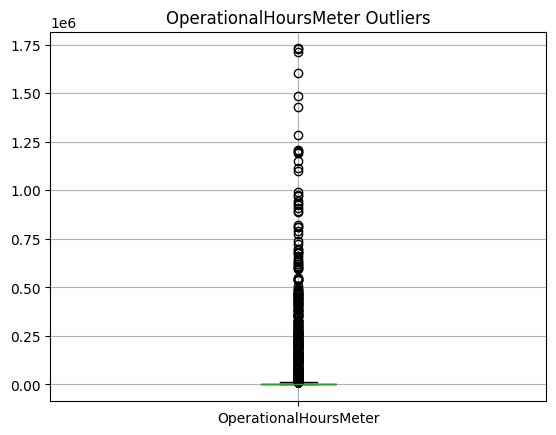

In [15]:
#boxplot for outlier
train.boxplot(column='OperationalHoursMeter')
plt.title('OperationalHoursMeter Outliers')
plt.show()

**Inference:**
- `OperationalHoursMeter` has a large number of extreme outliers 
- These extreme values are almost certainly data entry errors or placeholder values rather than real usage, which is why I clip them using IQR bounds instead of dropping the rows outright.

**6. Visualizing the distribution and missing values of categorical features**

CountPlot

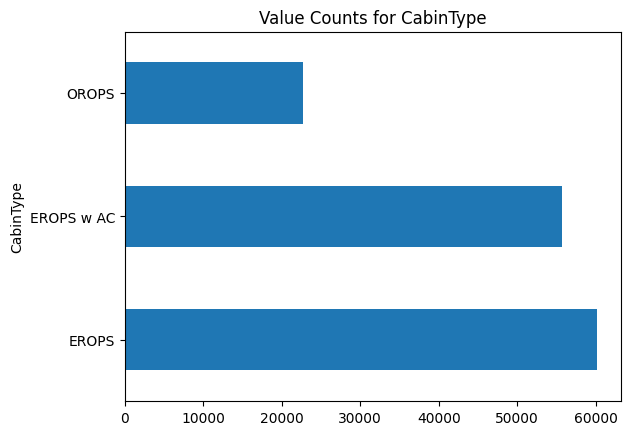

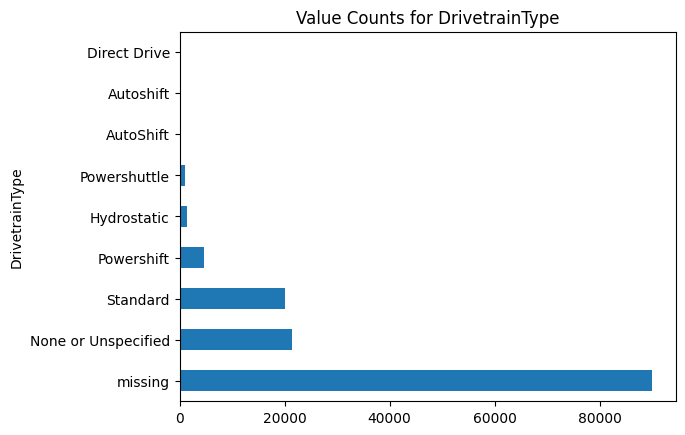

In [16]:
#Horizontal barcharts for categorical
for col in ['CabinType', 'DrivetrainType']:
    train[col].fillna('missing').value_counts().plot(kind='barh', title=f'Value Counts for {col}')
    plt.show()

**Inference:**
- Both 'CabinType' and 'DrivetrainType' are dominated by one or two categories.The rest making up a small share.
- 'DrivetrainType' has a large "missing" bucket means missing itself may carry information (e.g. it can correlate with a particular equipment type) so we can encode it as its own category instead of imputing blindly.

# Bivariate Analysis

**7. Correlation Heatmap of numerical features**

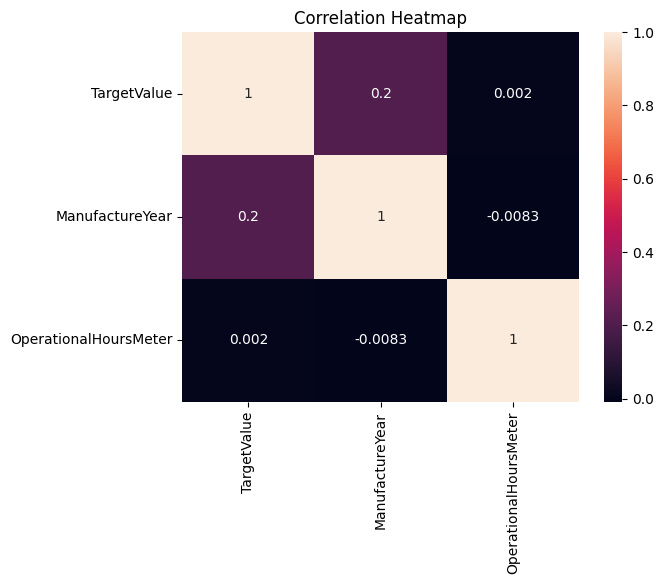

In [17]:
num_cols_corr = ['TargetValue', 'ManufactureYear', 'OperationalHoursMeter']
corr = train[num_cols_corr].corr()
sns.heatmap(corr, annot=True)
plt.title('Correlation Heatmap')
plt.show()

**Inference:**
- ManufactureYear shows a mild **positive** correlation with TargetValue — newer machines tend to sell for more.
- OperationalHoursMeter shows a mild **negative** correlation with TargetValue — more usage hours generally means more use of the product so it has a lower resale price.
- Both correlations are relatively weak or moderate in magnitude. This tells us price depends on a combination of many features (not just age/usage alone), so the model will need categorical and engineered features too.

**8. Numerical vs Target - Scatter plots**

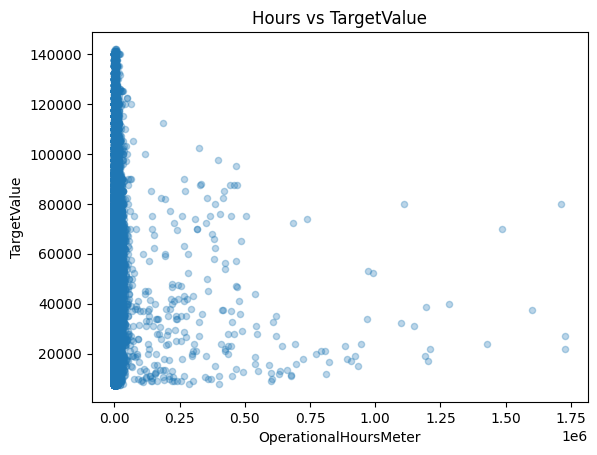

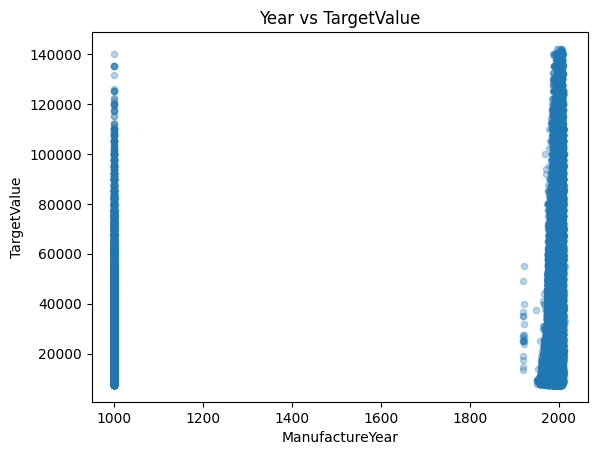

In [18]:
# Scatter plot for Hours vs Price
train.plot(kind='scatter', x='OperationalHoursMeter', y='TargetValue', alpha=0.3, title='Hours vs TargetValue')
plt.show()

# Scatter plot for Year vs Price
train.plot(kind='scatter', x='ManufactureYear', y='TargetValue', alpha=0.3, title='Year vs TargetValue')
plt.show()

**Inference:**
- The OperationalHoursMeter vs TargetValue scatter shows a loose downward trend: machines with very low hours cluster at higher prices, while high-hour machines rarely go for top prices — but the relationship is noisy, not a clean line.
- The ManufactureYear vs TargetValue scatter shows slight upward (positive) trend from left to right—newer machines generally go for higher prices. It means manufacture year matters but doesn't fully explain price by itself (equipment type, region, and condition also play a role). The wide price range within any single year proves that machine size/category, attachments, cabin type, and region play huge roles to dteremine final selling price.

**9. Numerical vs Target (log scale) - to handle skewness**

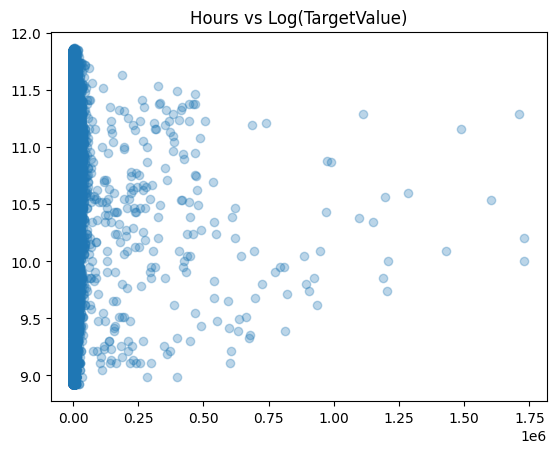

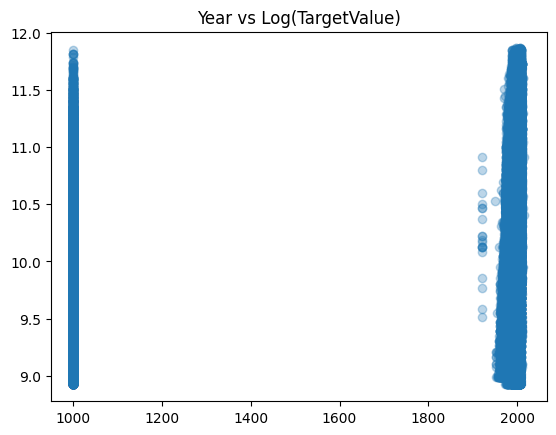

In [19]:
# Scatter plot (log scale) for Hours vs Price
plt.scatter(train['OperationalHoursMeter'], np.log(train['TargetValue']), alpha=0.3)
plt.title('Hours vs Log(TargetValue)')
plt.show()

# Scatter plot (log scale) for Year vs Price
plt.scatter(train['ManufactureYear'], np.log(train['TargetValue']), alpha=0.3)
plt.title('Year vs Log(TargetValue)')
plt.show()

**Inference:**
- On the log scale, both relationships look more linear and the extreme high-price/high-hour points are pulled in, so the trend is easier to see — this is a good sign that modeling log(TargetValue) with these features is good for linear/regularized models like Ridge.
- The spread of points is more even across the x-axis range on the log scale, compared to the outlier-dominated scattered view in the raw-scale plots above.

**10. Categorical vs Target - Boxplots**

<Figure size 1200x600 with 0 Axes>

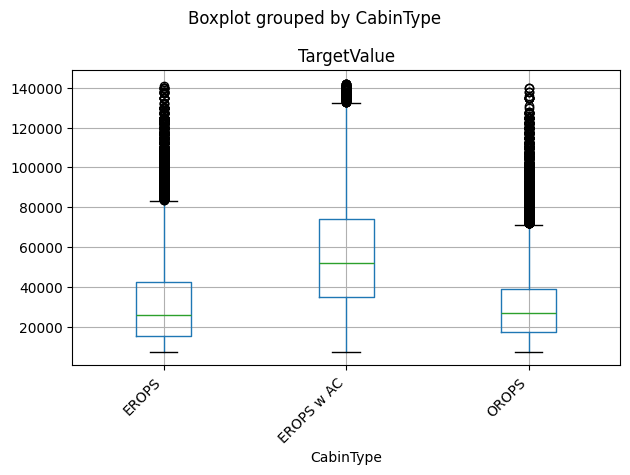

<Figure size 1200x600 with 0 Axes>

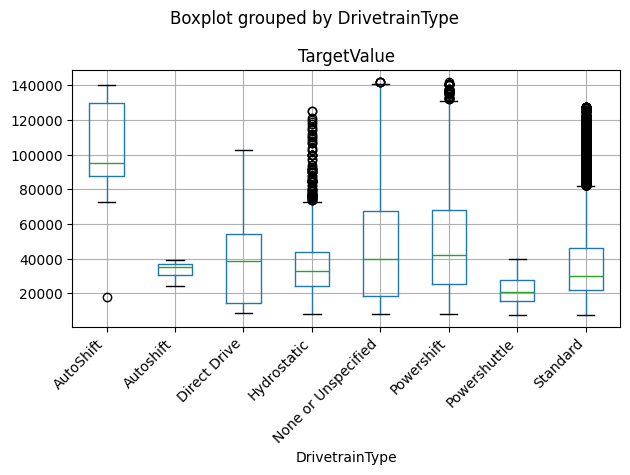

<Figure size 1200x600 with 0 Axes>

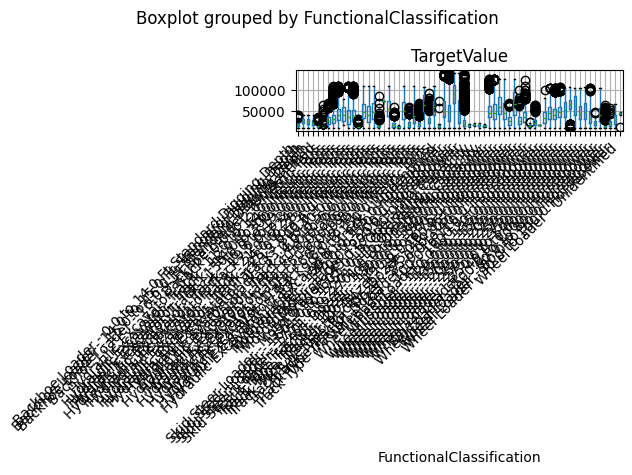

<Figure size 1200x600 with 0 Axes>

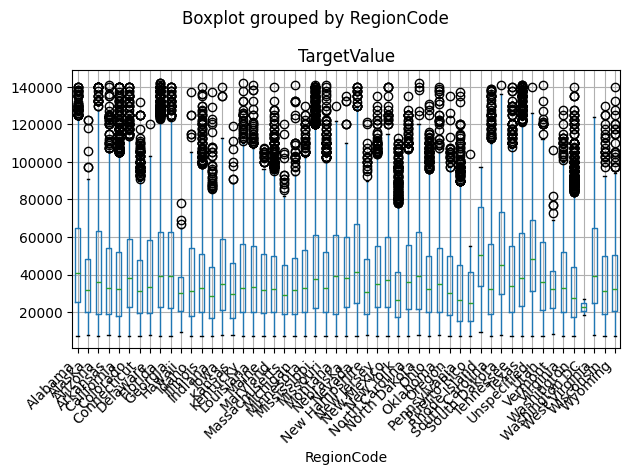

In [20]:
cat_cols_biv = ['CabinType', 'DrivetrainType', 'FunctionalClassification', 'RegionCode']
for col in cat_cols_biv:
    plt.figure(figsize=(12, 6))  # Sets wider size to add space between the boxes
    train.boxplot(column='TargetValue', by=col)
    plt.xticks(rotation=45, ha='right')  # Rotates and aligns text to prevent overlaps
    plt.tight_layout()  # Automatically adjusts spacing around labels
    plt.show()

**Inference:**
- Machines with better features (like enclosed cabins with AC) sell for significantly more money, making details like CabinType great price predictors.
- FunctionalClassification and RegionCode also show visible median differences across categories, meaning both equipment class and geography likely influence price and shouldn't be dropped during feature selection.
- Missing information isn't just blank space—it usually means a specific type of machine that didn't track that detail, so keeping "missing" as its own group helps predict prices better.

**11. Time-based bivariate: TransactionDate vs TargetValue**

LinePlot

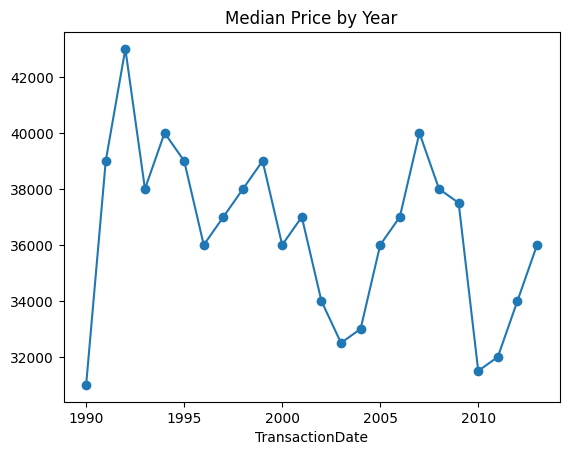

In [21]:
years = pd.to_datetime(train['TransactionDate']).dt.year
train.groupby(years)['TargetValue'].median().plot(kind='line', marker='o', title='Median Price by Year')
plt.show()

**Inference:**
- Median TargetValue fluctuates across transaction years. Equipment prices don't stay constant year after year—they rise and fall depending on the overall market and economy (for example, used equipment prices jump when new machines are expensive or in high demand).
- Because prices depend on when a machine was sold, creating time-based features (like TransactionYear or TransactionMonth) helps the model adjust for broader market trends rather than relying solely on the machine's age and specs.

**12. Pairwise relationships among key numerical features**

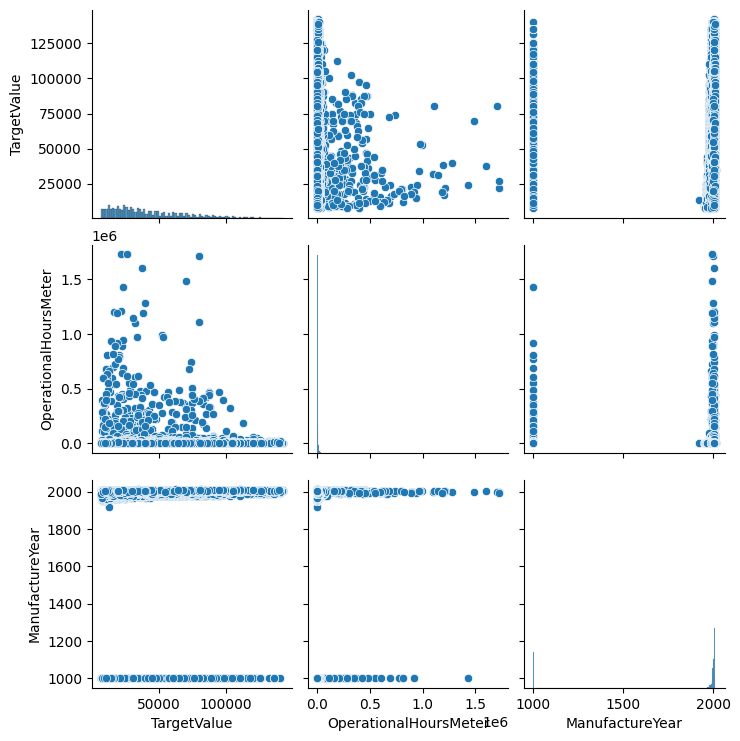

In [22]:
sns.pairplot(train[['TargetValue', 'OperationalHoursMeter', 'ManufactureYear']].dropna())
plt.show()

**Inference:**
- The pairplot confirms what we saw individually: TargetValue and OperationalHoursMeter are both right-skewed, while ManufactureYear is more evenly spread.
- The off-diagonal scatter panels show weak-to-moderate, noisy relationships rather than tight linear patterns — supporting the earlier conclusion that no single numerical feature dominates price, and the model will rely on a mix of numerical, categorical, and engineered features.

# Preprocessing

In [23]:
# Apply target transformation using standard natural logarithm (np.log)
y_log = np.log(train['TargetValue'])

During EDA, I saw that price is heavily right-skewed—most machines sell for lower/medium prices, but a few super expensive ones stretch out the scale. Log-transforming shrinks these high values down, making the price distribution bell-shaped (normal). This helps regression models (especially linear models like Ridge) make much better predictions.

**1. Duplicate handling**

In [24]:
train.drop_duplicates(subset=['TransactionID'], inplace=True)
y_log = y_log.loc[train.index]

If the exact same machine sale appears multiple times in my training data, the model might memorize those specific rows and work on them which is not needed.

# Train Test Split(Data Leakage Prevention)

In [25]:
train_indices, val_indices = train_test_split(train.index, test_size=0.2, random_state=42)

It prevents data leakage.It follows split first calculate second.Train.index create strict barrier. So like normal train test split during mathematical calculation(quantile,min,mean),my validation set will not be exposed.

**2. Clean invalid placeholders**

In [26]:
train['ManufactureYear'] = train['ManufactureYear'].replace(1001, np.nan)
train['OperationalHoursMeter'] = train['OperationalHoursMeter'].replace(0.0, np.nan)
test['ManufactureYear'] = test['ManufactureYear'].replace(1001, np.nan)
test['OperationalHoursMeter'] = test['OperationalHoursMeter'].replace(0.0, np.nan)

Year 1001 and 0 usage hours aren't real physical numbers—they are default dummy codes entered when the system didn't know the true value. If it left as it is the model might calculate on this and think that a machine was built 1000 years ago. So imputing them to NaN allows to treat them correctky as missing values.

**3. Outlier clipping using IQR boundaries calculated from train**

In [27]:
#Used train.loc for data leakage prevention so the validation and test set has zero influence on where the outlier cutoffs set
Q1 = train.loc[train_indices, 'OperationalHoursMeter'].quantile(0.25)
Q3 = train.loc[train_indices, 'OperationalHoursMeter'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
train['OperationalHoursMeter'] = train['OperationalHoursMeter'].clip(lower=lower_bound, upper=upper_bound) #clipped the value if it is >upperbound to upperbound and if it is <lowerbound to lowerbound
test['OperationalHoursMeter'] = test['OperationalHoursMeter'].clip(lower=lower_bound, upper=upper_bound)

Heavy equipment sometimes has crazy data entry errors (like a machine showing over 1,000,000 operational hours). Instead of deleting these entire rows and losing valuable information, clipping caps extreme outliers at a reasonable maximum.

**4. Impute string columns to a constant 'missing'**

In [28]:
cat_cols_raw = train.select_dtypes(include='object').columns.tolist()#tolist converts it to python list so that I can use loop
for col in cat_cols_raw:
    train[col] = train[col].fillna('missing').astype(str) #astype(str) to confirm that no hidden numerical or float value remains in categorical columns
    test[col] = test[col].fillna('missing').astype(str)

In real-world data, a blank space often isn't random—it usually means a specific category or machine type where that feature wasn't tracked (e.g., open-cabin machines won't have air-conditioning options). Treating 'missing' as its own explicit group lets tree-based algorithms pick up patterns hidden within missing information.

In [29]:
print('Data preprocessing completed.')

Data preprocessing completed.


# Feature Engineering

In [30]:
#To prevent dataleakage used this train.loc so only from train dataset we get min date or baseline date
min_date_ref = pd.to_datetime(train.loc[train_indices, 'TransactionDate'].min())#Prevention of data leakage

# Extracting some columns from date numerical column. Now it can be evaluaated based on day-month and year trends
for df_temp in [train, test]:
    dates = pd.to_datetime(df_temp['TransactionDate'])
    df_temp['TxYear'] = dates.dt.year
    df_temp['TxMonth'] = dates.dt.month
    df_temp['TxDay'] = dates.dt.day
    df_temp['TxDayOfWeek'] = dates.dt.dayofweek#0 for monday and 6 for sunday
    df_temp['TxDayOfYear'] = dates.dt.dayofyear
    df_temp['TxWeekOfYear'] = dates.dt.isocalendar().week.astype(int)#isocalender breaks the date into year,week and weekday
    df_temp['TxIsWeekend'] = (df_temp['TxDayOfWeek'] >= 5).astype(int)#takes sat(5) and sun(6) as weekend and returns yes
    
    # A numerical feature explaining no. of days passed between transaction date and baseline date like how many days passed between first sale(baseline date) and any other sale
    df_temp['TxDateElapsed'] = (dates - min_date_ref).dt.days#.days transform the date perfectly how many days like 9 days 10 days etc
    
    #Manufacture year alone doesn't tell the full story. Buyers more care about the machine age than manufacture year. This is one of the direct predictors of the sale price
    df_temp['MachineAge'] = df_temp['TxYear'] - df_temp['ManufactureYear']
    
    #clipped values below zero (clip(lower=0)) to handle potential data anomalies where sale date preceded manufacture date.
    df_temp['MachineAge'] = df_temp['MachineAge'].clip(lower=0)#if machineage negative it transformed to 0

    #Machine age don't tell how much hours it has been used.So HoursPerYear will tell work intensity of the machine.For new machine machineage will be 0 so to prevent dividing by 0 I have added 1 in the denominator
    df_temp['HoursPerYear'] = df_temp['OperationalHoursMeter'] / (df_temp['MachineAge'] + 1)

**Inference**

- By creating TxDateElapsed, you convert a calendar date (e.g., 2005-03-26) into a single continuous integer (e.g., 5533 days).LightGBM can easily split the decision trees.
- By extracting month year columns from date numerical feature **Tree-based models** can now split on specific months or years to capture market inflation, seasonal buying sprees, and time-dependent price fluctuations.
- By creating **MachineAge**(one of the strongest direct price predictor) , it gives models a clean and linear representation of physical age and depreciation at time of purchase.
- By creating **HoursPerYear** , it represent work intensity. High intensity machines have done much more work in less time so its resale value will be low.

In [31]:
# Drop identifiers
drop_cols = ['TransactionID', 'TransactionDate', 'TargetValue']
X_train_raw = train.drop([c for c in drop_cols if c in train.columns], axis=1)
X_test_raw  = test.drop([c for c in drop_cols if c in test.columns], axis=1)

**Inference**

- By dropping identifier columns, models can now be trained prefectly without doing any uncorrelated or extra useless calculations(not important)

**Ordinal Encoding**

In [32]:
#Filtered our existing cat_cols_raw variable to exclude dropped columns
cat_cols = [c for c in cat_cols_raw if c not in drop_cols]

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)#if anything unknown or unusual data present Handle_unknown handles it and make it to 0
encoder.fit(X_train_raw.loc[train_indices, cat_cols])#Encoded only train columns to prevent data leakage

X_train_raw[cat_cols] = encoder.transform(X_train_raw[cat_cols])
X_test_raw[cat_cols]  = encoder.transform(X_test_raw[cat_cols])

**Inference**

- Machine learning models operate on numbers, not text strings. Converting text columns into integers allows tree-based models to navigate branches efficiently.

In [33]:
# Cast categories to category dtype for native splitting
for col in cat_cols:
    X_train_raw[col] = X_train_raw[col].astype(int).astype('category')
    X_test_raw[col]  = X_test_raw[col].astype(int).astype('category')

print('Feature Engineering completed.')

Feature Engineering completed.


**Inference**

- After converting text columns into integers (ordinal encoding), pandas still treats those columns as standard numbers (int64). Specialized tree-based libraries like LightGBM and XGBoost have built-in algorithms specifically designed to handle categorical data. Converting these integer columns into pandas' explicit category type gives a clear signal to the model to treat them as distinct categories rather than continuous numerical numbers.

# Train-Test Split

In [34]:
X_train_fit = X_train_raw.loc[train_indices]
X_val_fit = X_train_raw.loc[val_indices]
y_train_fit = y_log.loc[train_indices]
y_val_fit = y_log.loc[val_indices]
y_val_orig = np.exp(y_val_fit)#To calculate performance metrics like R^2

# Model Building

In [35]:
num_cols = X_train_fit.select_dtypes(exclude=['category']).columns.tolist()

# Preprocessor definition
linear_num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),#Imputes missing numerical values using the median.Many columns(like operationalhoursmeter) contain heavy outlier so use median
    ('scaler', StandardScaler()) #Scales all numerical features using StandardScaler (subtracts mean, divides by standard deviation).
])

# 1. Linear Preprocessor: scales numericals and imputes missing categories
linear_preprocessor = ColumnTransformer(
    transformers=[
        ('num', linear_num_transformer, num_cols)
    ],
    remainder=SimpleImputer(strategy='constant', fill_value=-1)#Fills any missing values with -1
)
linear_preprocessor.set_output(transform='pandas')

# 2. Tree Preprocessor: pure passthrough (retains NaNs and category dtype for native splits)
tree_preprocessor = ColumnTransformer(
    transformers=[],
    remainder='passthrough'
)
tree_preprocessor.set_output(transform='pandas')

ColumnTransformer(remainder='passthrough', transformers=[])

**Inference**

- **For linear preprocessor** :  Linear models (Ridge, LinearSVR) and Random Forest (when configured for standard arrays) struggle with raw scale differences. Scaling puts all numbers on an equal playing field.
- **For tree preprocessor** : I have just passed through the raw data as tree models are smarter. When XGBoost or LightGBM see a missing value (NaN), they automatically test sending it down the left branch vs. the right branch and learn which path gives better predictions. Passing pandas category dtypes, because tree model can group naturally

# Ridge Regression

In [36]:
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', linear_preprocessor),
    ('model', Ridge(alpha=10.0))
])
# Train and predict Ridge model
ridge_pipeline.fit(X_train_fit, y_train_fit)
y_pred_log = ridge_pipeline.predict(X_val_fit)

# Calculate metrics
ridge_r2 = r2_score(y_val_orig, np.exp(y_pred_log))
ridge_rmsle = np.sqrt(np.mean((y_pred_log - y_val_fit)**2))
print(f"Ridge R2: {ridge_r2:.4f} | RMSLE: {ridge_rmsle:.4f}")

Ridge R2: 0.4590 | RMSLE: 0.4712


Ridge regression will be best for this as price feature relationships can suffer from multicollinearity (features being correlated with each other), Ridge uses L_2 regularization (alpha = 10.0) to penalize large weights and keep coefficients stable.

# Linear Support vector regressor(SVR)

In [37]:
svr_pipeline = Pipeline(steps=[
    ('preprocessor', linear_preprocessor),
    ('model', LinearSVR(C=1.0, random_state=42))
])
# Train and predict LinearSVR model
svr_pipeline.fit(X_train_fit, y_train_fit)
y_pred_log = svr_pipeline.predict(X_val_fit)

# Calculate metrics directly
svr_r2 = r2_score(y_val_orig, np.exp(y_pred_log))
svr_rmsle = np.sqrt(np.mean((y_pred_log - y_val_fit)**2))
print(f"LinearSVR R2: {svr_r2:.4f} | RMSLE: {svr_rmsle:.4f}")

LinearSVR R2: -3.9135 | RMSLE: 0.9562


Linear SVR uses an epsilon-insensitive loss function. It ignores small error s within a margn. This makes it less sensitive to extreme price outliers than standard least-squares regression.

# XGBoost Regressor

In [38]:

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', tree_preprocessor),
    ('model', XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=2, enable_categorical=True))
])
# Train and predict XGBoost model
xgb_pipeline.fit(X_train_fit, y_train_fit)
y_pred_log = xgb_pipeline.predict(X_val_fit)

# Calculate metrics 
xgb_r2 = r2_score(y_val_orig, np.exp(y_pred_log))
xgb_rmsle = np.sqrt(np.mean((y_pred_log - y_val_fit)**2))
print(f"XGBoost R2: {xgb_r2:.4f} | RMSLE: {xgb_rmsle:.4f}")

XGBoost R2: 0.8908 | RMSLE: 0.2157


XGBoost is a powerful Gradient Boosted Decision Tree (GBDT) framework that builds sequential trees, where each tree corrects the errors of the previous ones. So in final we can get a less errored output.

# Random Forest Regressor

In [39]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', linear_preprocessor),
    ('model', RandomForestRegressor(n_estimators=50, max_depth=12, random_state=42, n_jobs=2))
])
# Train and predict Random Forest model
rf_pipeline.fit(X_train_fit, y_train_fit)
y_pred_log = rf_pipeline.predict(X_val_fit)

# Calculate metrics 
rf_r2 = r2_score(y_val_orig, np.exp(y_pred_log))
rf_rmsle = np.sqrt(np.mean((y_pred_log - y_val_fit)**2))
print(f"Random Forest R2: {rf_r2:.4f} | RMSLE: {rf_rmsle:.4f}")

Random Forest R2: 0.8289 | RMSLE: 0.2662


Random Forest Regressor is a tree-based ensemble model to capture non-linear relationships. Random Forest builds multiple independent decision trees in parallel and averages their predictions. Restricting the depth (max_depth = 12) prevents overfitting.

# Stacking Regressor

In [40]:
# Setup and train Stacking Regressor
estimators = [
    ('ridge', ridge_pipeline),
    ('rf',    rf_pipeline),
    ('xgb',   xgb_pipeline)
]
stacking = StackingRegressor(estimators=estimators, final_estimator=Pipeline(steps=[('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))]), cv=3, n_jobs=1)
stacking.fit(X_train_fit, y_train_fit)
y_pred_log = stacking.predict(X_val_fit)

# Calculate metrics 
stack_r2 = r2_score(y_val_orig, np.exp(y_pred_log))
stack_rmsle = np.sqrt(np.mean((y_pred_log - y_val_fit)**2))
print(f"Stacking R2: {stack_r2:.4f} | RMSLE: {stack_rmsle:.4f}")

Stacking R2: 0.8920 | RMSLE: 0.2154


Stacking Regressor combines predictions from my base models (Ridge, Random Forest, XGBoost) and feeds them into a secondary Ridge meta-model to learn when to trust which model.

# Hyperparameter Tuning

Hyperparameter tuned RandomForestRegressor

In [41]:
X_tune, _, y_tune, _ = train_test_split(X_train_fit, y_train_fit, train_size=0.05, random_state=42)
rf_params = {
    'model__n_estimators': [30, 50],
    'model__max_depth': [8, 12]
}
rf_tune = RandomizedSearchCV(rf_pipeline, rf_params, n_iter=2, cv=2, scoring='r2', n_jobs=1, random_state=42)
rf_tune.fit(X_tune, y_tune)
print('Best RF params:', rf_tune.best_params_)
print('Best RF Score:', round(rf_tune.best_score_, 4))

Best RF params: {'model__n_estimators': 50, 'model__max_depth': 12}
Best RF Score: 0.7657


**Inference**

- Prevents Overfitting : Finds the right depth and tree count (max_depth, n_estimators) so the model doesn't memorize training noise and generalizes well to new data.
- Find best parameter : Uses RandomizedSearchCV with cross-validation to systematically find the best parameters based on R^2 score instead of manual guessing.
- Saves Time : Runs the search on a quick 5% subset (X_tune) to test settings in seconds before scaling up to full models.

# Comparison of Model Performance

=== MODEL LEADERBOARD ===
        Model  R2_Score
     Stacking  0.891992
      XGBoost  0.890752
Random Forest  0.828891
        Ridge  0.459014
    LinearSVR -3.913493


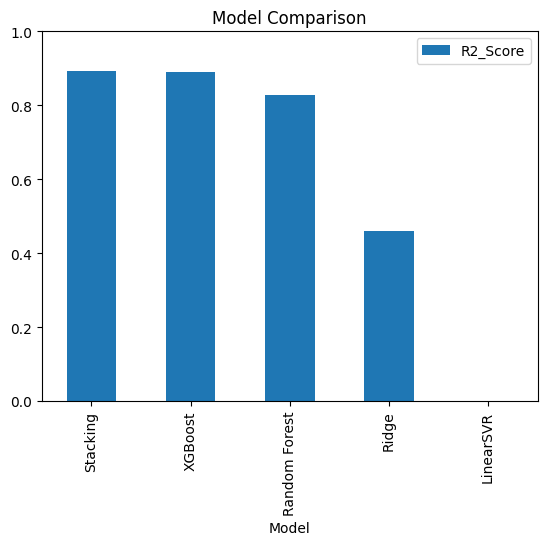

In [42]:
scores = {
    'Ridge': ridge_r2,
    'LinearSVR': svr_r2,
    'XGBoost': xgb_r2,
    'Random Forest': rf_r2,
    'Stacking': stack_r2
}
results_df = pd.DataFrame(scores.items(), columns=['Model', 'R2_Score'])
results_df = results_df.sort_values('R2_Score', ascending=False)

print('=== MODEL LEADERBOARD ===')
print(results_df.to_string(index=False))

# Simple bar chart comparison
results_df.plot(kind='bar', x='Model', y='R2_Score', title='Model Comparison')
plt.ylim(0, 1)
plt.show()

**Inference:**
- Tree based models like XGBoost,Random Forest outperform linear models. It captures the non linear pattern of the dataset well.
- With an R^2 of 0.8908 and RMSLE of 0.2157, XGBoost single-handedly captures almost all price variance. 
- The Stacking Regressor combines predictions from Ridge, Random Forest, and XGBoost using a Ridge meta-model.

# Preparing Test Dataset

As tree based model doing well with the dataset we can try lightgbm.LightGBM Regressor used for my final high-capacity test pipeline. LightGBM is extremely fast and handles large tabular datasets with high cardinality categories effortlessly. Its leaf-wise tree growth enables it to achieve high accuracy on complex heavy-equipment pricing patterns.

In [43]:
latest_pipeline = Pipeline(steps=[
    ('preprocessor', tree_preprocessor),
    ('model', LGBMRegressor(
        n_estimators=1200,
        learning_rate=0.03,
        num_leaves=255,
        min_child_samples=15,
        random_state=42,
        n_jobs=2,
        verbose=-1
    ))
])
# Train and predict LightGBM model
latest_pipeline.fit(X_train_fit, y_train_fit)
y_pred_log = latest_pipeline.predict(X_val_fit)

# Calculate metrics directly
latest_r2 = r2_score(y_val_orig, np.exp(y_pred_log))
latest_rmsle = np.sqrt(np.mean((y_pred_log - y_val_fit)**2))
print(f"LightGBM R2: {latest_r2:.4f} | RMSLE: {latest_rmsle:.4f}")

LightGBM R2: 0.9103 | RMSLE: 0.1986


As expected LightGBM outperforms every model

# File submission

In [44]:
print("Training the final model (LightGBM) on full training set for optimal test performance")
latest_pipeline.fit(X_train_raw, y_log)

test_preds_log = np.clip(latest_pipeline.predict(X_test_raw), 0, 13)
test_preds = np.exp(test_preds_log)

sample_sub['TargetValue'] = test_preds
sample_sub.to_csv('submission.csv', index=False)
print('submission.csv saved using LightGBM pipeline!')
print(sample_sub.head())

Training the final model (LightGBM) on full training set for optimal test performance
submission.csv saved using LightGBM pipeline!
   TransactionID   TargetValue
0        1139307  66452.741256
1        1139419  78964.758963
2        1139482  31119.110022
3        1139522  20035.042626
4        1139684  12466.640694
